In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import scipy.linalg as la

\begin{equation}
\dot{x} = Ax + Bu
\end{equation}

\begin{equation}
y = Cx
\end{equation}

\begin{equation}
\dot{w}_g = S_g w_g
\end{equation}

\begin{equation}
u = L_g w_g
\end{equation}

Consider a system where $A$ and $S_g$ are not Hurwitz. 



<bound method Axes.scatter of <Axes: >>

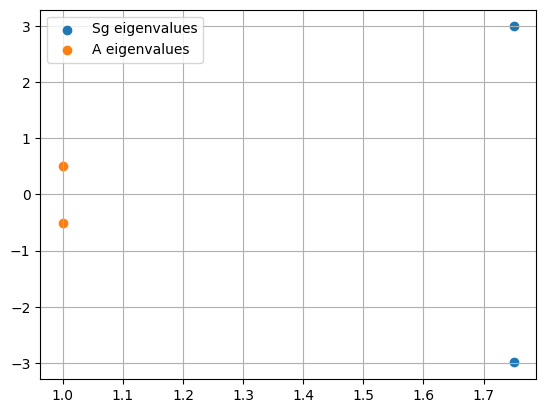

In [27]:
A = np.array([[1.0, -0.5],
              [0.5, 1.0]])

B = np.array([[0.],
              [1.]])

C = np.array([[1.0, 1.0]])

Sg = np.array([[2.0, -3.],
               [3., 1.5]])

Lg = np.array([[1.0, 1.0]])

def eigenvalue_list_creator(Sg):
    Re = []
    Im = []
    for z in np.linalg.eigvals(Sg):
        Re.append(np.real(z))
        Im.append(np.imag(z))
    return Re, Im

Re_Sg, Im_Sg = eigenvalue_list_creator(Sg)
Re_A, Im_A = eigenvalue_list_creator(A)


fig, ax = plt.subplots()
ax.scatter(Re_Sg, Im_Sg, label = 'Sg eigenvalues')
ax.scatter(Re_A, Im_A, label = 'A eigenvalues')

ax.legend()
ax.grid(True)
ax.scatter

Eigenvalues are not shared, and are both on the right handside. 
Now let's simulate the dynamics of the system, and look at the moment relationships. 

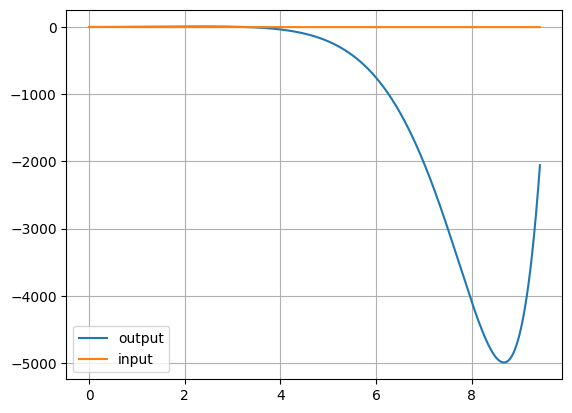

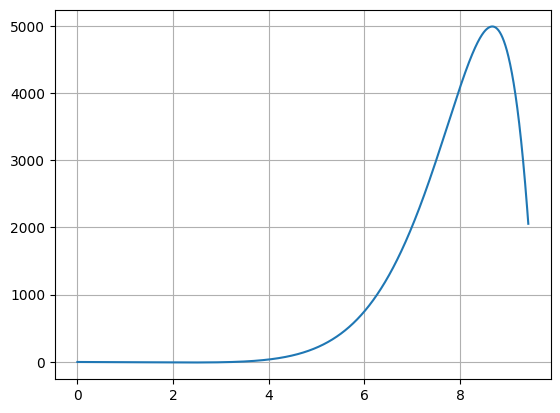

In [26]:
def system(t, state):
    x = state[:2]
    w = state[2:4]

    u = Lg @ w
    dx = A @ x + B.flatten() * u
    dw = Sg @ w
    return np.concatenate([dx, dw])

# Time conditions
t_span = (0., 3.0*np.pi)
t_eval = np.linspace(t_span[0], t_span[1], 10000)

# Initial conditions
x0 = [1.0, 0.2, 2.0, 0.5]
sol = solve_ivp(system, t_span, x0, t_eval=t_eval, method='Radau')

X = sol.y[:2, :]
Y = (C @ X).flatten()

W = sol.y[2:, :]
U = (Lg @ W).flatten()

# Moments
Pi_g = la.solve_sylvester(A, -Sg, -B @ Lg)
Mg = C @ Pi_g
moment_output = (Mg @ W).flatten()
diff = moment_output - Y


plt.figure(1)
plt.plot(sol.t, Y, label = 'output')
plt.plot(sol.t, U, label = 'input')
plt.grid(True)
plt.legend()

plt.figure(2)
plt.plot(sol.t, diff)
plt.grid(True)

plt.show()